# Predicting Exoplanet Habitability Using Machine Learning
## Week 2: Data Cleaning & Feature Engineering

### Objective
To clean raw astronomical data, handle missing values and outliers, 
and engineer meaningful features that can improve habitability analysis.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [4]:

df = pd.read_csv(
    r"C:\Users\tumar\Desktop\ExoHabit-AI\data\raw\exoplanet_raw.csv",
    comment="#"
)

df.head()


C:\Users\tumar\AppData\Local\Temp\ipykernel_24520\2919426187.py:1: DtypeWarning: Columns (0: hd_name, 1: hip_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,2023-09-19,2023-08,2023-09-19,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-05-14,2008-01,2014-05-14,2.0,1.0,2.0,0.0,0.0,0.0,0.0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-07-23,2011-08,2014-07-23,2.0,1.0,2.0,0.0,0.0,0.0,0.0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,2018-04-25,2009-10,2014-05-14,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,2018-09-04,2017-03,2018-09-06,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 1. Missing Value Analysis


In [5]:
missing = df.isnull().sum()
missing[missing > 0]


hd_name         36309
hip_name        36043
tic_id            783
gaia_dr2_id      1085
gaia_dr3_id      1322
                ...  
st_nrvc            50
st_nspec           50
pl_nespec          50
pl_ntranspec       50
pl_ndispec         50
Length: 111, dtype: int64

### Missing Value Handling Strategy
Missing values occur due to limitations in astronomical observations.
Numerical features will be handled using median imputation to reduce
the effect of outliers.
Categorical features will be handled using mode imputation.


In [6]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [7]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode().iloc[0]))


In [8]:
df.isnull().sum().sum()


np.int64(0)

## 3. Outlier Analysis

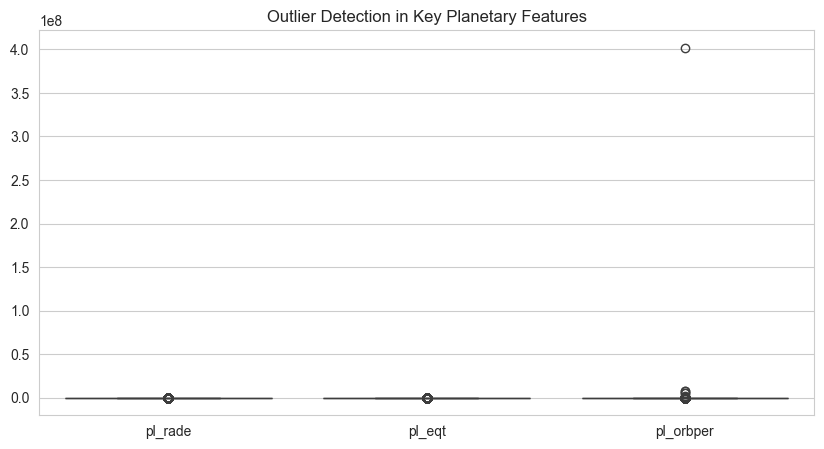

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['pl_rade','pl_eqt','pl_orbper']])
plt.title("Outlier Detection in Key Planetary Features")
plt.show()


### Outlier Handling
Extreme values are expected in astronomical datasets.
Instead of removal, values are retained to preserve scientific diversity
and avoid loss of rare but meaningful planetary cases.


In [10]:
df['st_spectype_simple'] = df['st_spectype'].astype(str).str[0]
df[['st_spectype', 'st_spectype_simple']].head()


,st_spectype,st_spectype_simple
0,G8 III,G
1,G8 III,G
2,G0 V,G
3,K4 III,K
4,G0 V,G


Spectral classes are simplified to reduce dimensionality while 
preserving stellar characteristics.


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


### Habitability Score Engineering

A synthetic habitability index is constructed based on proximity
to Earth-like equilibrium temperature and radius values.
The score ranges between 0 and 1.


In [12]:
df['habitability_score'] = (
    (1 - abs(df['pl_eqt'] - 0.5)) *
    (1 - abs(df['pl_rade'] - 0.5))
)

df[['pl_eqt','pl_rade','habitability_score']].head()


,pl_eqt,pl_rade,habitability_score
0,0.18999,0.000474,0.345322
1,0.18999,0.000474,0.345322
2,0.18999,0.000474,0.345322
3,0.18999,0.000474,0.345322
4,0.18999,0.000474,0.345322


A custom habitability score is created using normalized temperature
and planet size, approximating Earth-like conditions.


In [13]:
df['stellar_compatibility'] = 1 - abs(df['st_teff'] - 0.5)
df[['st_teff','stellar_compatibility']].head()


,st_teff,stellar_compatibility
0,0.078802,0.578802
1,0.076469,0.576469
2,0.091862,0.591862
3,0.069365,0.569365
4,0.067120,0.567120


## 6. Post-Cleaning Correlation Validation

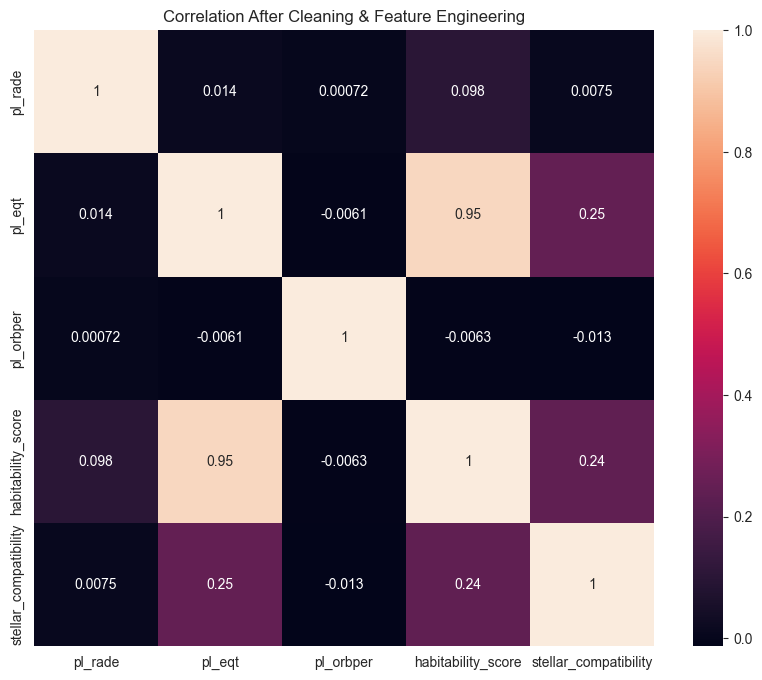

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[['pl_rade','pl_eqt','pl_orbper',
        'habitability_score','stellar_compatibility']].corr(),
    annot=True
)
plt.title("Correlation After Cleaning & Feature Engineering")
plt.show()


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def load_data(path):
    """Load dataset"""
    return pd.read_csv(path, comment="#")


def handle_missing_values(df):
    """Handle missing values"""
    num_cols = df.select_dtypes(include='number').columns
    cat_cols = df.select_dtypes(include=['object', 'string']).columns

    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    for col in cat_cols:
        if df[col].mode().empty:
            df[col] = df[col].fillna("Unknown")
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df


def encode_categorical(df):
    """Simplify star spectral type"""
    if 'st_spectype' in df.columns:
        df['st_spectype_simple'] = df['st_spectype'].astype(str).str[0]

    return df


def scale_features(df):
    """Normalize numeric features"""
    scaler = MinMaxScaler()

    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df


def engineer_features(df):
    """Create habitability and stellar features"""

    # Avoid missing columns
    if 'pl_eqt' in df.columns and 'pl_rade' in df.columns:
        df['habitability_score'] = (
            (1 - abs(df['pl_eqt'] - 0.5)) *
            (1 - abs(df['pl_rade'] - 0.5))
        )

    if 'st_teff' in df.columns:
        df['stellar_compatibility'] = 1 - abs(df['st_teff'] - 0.5)

    # Additional strong features 🔥
    if 'pl_orbper' in df.columns:
        df['orbital_stability'] = 1 / (1 + df['pl_orbper'])

    if 'pl_rade' in df.columns and 'pl_bmasse' in df.columns:
        df['density_proxy'] = df['pl_bmasse'] / (df['pl_rade']**3 + 1e-5)

    return df


def select_features(df):
    """Select important columns"""
    selected = [
        'pl_rade', 'pl_eqt', 'pl_orbper',
        'habitability_score', 'stellar_compatibility'
    ]

    selected = [col for col in selected if col in df.columns]

    return df[selected]


def preprocess_pipeline(path):
    """Complete preprocessing pipeline"""

    df = load_data(path)

    df = handle_missing_values(df)
    df = encode_categorical(df)
    df = scale_features(df)
    df = engineer_features(df)

    return df


In [16]:
df.to_csv("../data/processed/exoplanet_cleaned.csv", index=False)


In [17]:
# Habitable zone feature (Goldilocks zone)
if 'pl_eqt' in df.columns:
    df['habitable_zone'] = df['pl_eqt'].apply(
        lambda x: 1 if 0.3 <= x <= 0.7 else 0
    )

# Earth similarity index (simplified)
if 'pl_rade' in df.columns:
    df['earth_similarity'] = 1 - abs(df['pl_rade'] - 0.5)


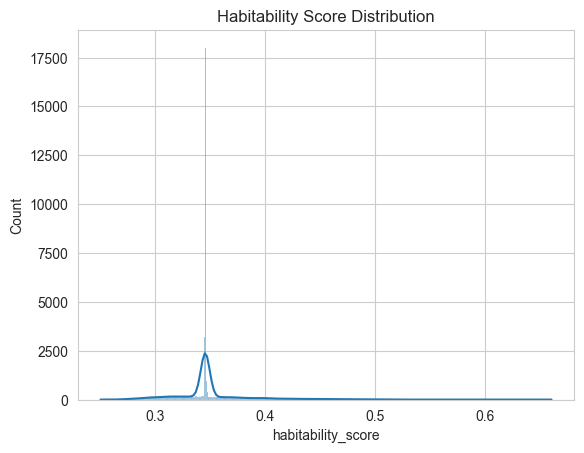

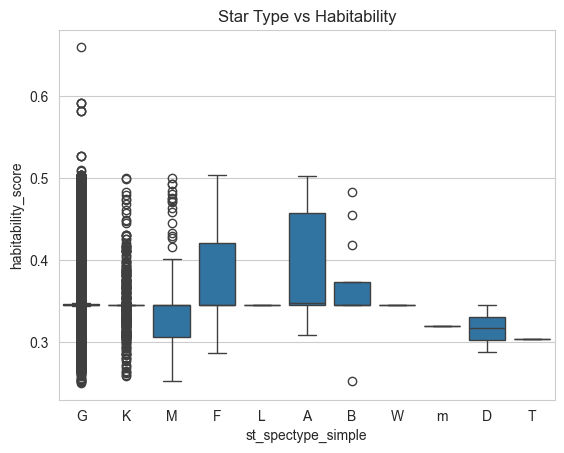

In [18]:
# Distribution of habitability
sns.histplot(df['habitability_score'], kde=True)
plt.title("Habitability Score Distribution")
plt.show()

# Star type vs habitability
sns.boxplot(x='st_spectype_simple', y='habitability_score', data=df)
plt.title("Star Type vs Habitability")
plt.show()


## Week 2: Data Cleaning and Feature Engineering

The raw exoplanet dataset contained missing values, outliers, and 
inconsistent categorical data due to limitations in astronomical observations.

### Missing Value Handling
Numerical features were imputed using median values to minimize the 
impact of extreme observations. Categorical variables were imputed 
using mode values.

### Outlier Handling
Outliers were retained because extreme planetary values are scientifically 
significant and may represent rare habitable environments.

### Feature Encoding
The stellar spectral type was simplified into a single character to 
reduce dimensionality while preserving stellar classification.

### Feature Scaling
All numerical features were normalized using Min-Max scaling to ensure 
uniformity across features.

### Feature Engineering
New features were created:
- Habitability Score Index
- Stellar Compatibility Index
- Orbital Stability
- Density Proxy
- Earth Similarity Index

These features improve model understanding of habitability conditions.

### Validation
Correlation analysis was performed to validate relationships between 
features and habitability indicators.

The processed dataset is now ready for machine learning.
